In [1]:
import numpy as np
import tensorflow as tf

# -------------------------------
# Functions (1D, 2D, 3D)
# -------------------------------
def f_1d(x):
    return np.sin(12 * x) + 0.5 * np.cos(20 * x)


def f_2d(x, y):
    return (
        np.sin(12 * x) * np.cos(12 * y)
        + 0.7 * np.sin(8 * (x + y))
        + 0.3 * np.cos(20 * x * y)
    )


def f_3d(x, y, z):
    return (
        np.sin(10 * x) * np.cos(10 * y) * np.sin(10 * z)
        + 0.5 * np.cos(15 * x * y)
        + 0.3 * np.sin(12 * (x + y + z))
    )

# -------------------------------
# Fixed-point quantization
# -------------------------------
def to_fixed(x, frac_bits):
    scale = 2 ** frac_bits
    return np.round(x * scale) / scale

# -------------------------------
# Model builder
# -------------------------------
def build_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse'
    )

    return model

# -------------------------------
# Train helper
# -------------------------------
def train_nn(X, residual):
    mean = residual.mean()
    std = residual.std() + 1e-8
    y = (residual - mean) / std

    model = build_model(X.shape[1])

    model.fit(
        X, y,
        epochs=400,
        batch_size=256,
        verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                patience=30,
                restore_best_weights=True
            )
        ]
    )

    return model, mean, std

# -------------------------------
# Experiment per dimension
# -------------------------------
def run_experiment(dim, frac_bits):
    np.random.seed(0)

    N_train = 20000
    N_test = 8000

    X_train = np.random.rand(N_train, dim)
    X_test = np.random.rand(N_test, dim)

    # True function
    if dim == 1:
        y_train = f_1d(X_train[:, 0])
        y_test = f_1d(X_test[:, 0])
    elif dim == 2:
        y_train = f_2d(X_train[:, 0], X_train[:, 1])
        y_test = f_2d(X_test[:, 0], X_test[:, 1])
    else:
        y_train = f_3d(X_train[:, 0], X_train[:, 1], X_train[:, 2])
        y_test = f_3d(X_test[:, 0], X_test[:, 1], X_test[:, 2])

    # Fixed-point inputs
    X_train_fp = to_fixed(X_train, frac_bits)
    X_test_fp = to_fixed(X_test, frac_bits)

    # Fixed-point eval
    if dim == 1:
        y_fp_train = f_1d(X_train_fp[:, 0])
        y_fp_test = f_1d(X_test_fp[:, 0])
    elif dim == 2:
        y_fp_train = f_2d(X_train_fp[:, 0], X_train_fp[:, 1])
        y_fp_test = f_2d(X_test_fp[:, 0], X_test_fp[:, 1])
    else:
        y_fp_train = f_3d(X_train_fp[:, 0], X_train_fp[:, 1], X_train_fp[:, 2])
        y_fp_test = f_3d(X_test_fp[:, 0], X_test_fp[:, 1], X_test_fp[:, 2])

    mse_fp = np.mean((y_fp_test - y_test) ** 2)

    residual = y_train - y_fp_train

    results = {}

    # -----------------------
    # Case 1: NN(x)
    # -----------------------
    nn1, m1, s1 = train_nn(X_train, residual)
    pred1 = nn1.predict(X_test, verbose=0).reshape(-1)
    y1 = y_fp_test + pred1 * s1 + m1
    results['NN(x)'] = np.mean((y1 - y_test) ** 2)

    # -----------------------
    # Case 2: NN(x_fp)
    # -----------------------
    nn2, m2, s2 = train_nn(X_train_fp, residual)
    pred2 = nn2.predict(X_test_fp, verbose=0).reshape(-1)
    y2 = y_fp_test + pred2 * s2 + m2
    results['NN(x_fp)'] = np.mean((y2 - y_test) ** 2)

    # -----------------------
    # Case 3: NN(x, x_fp)
    # -----------------------
    X_train_full = np.concatenate([X_train, X_train_fp], axis=1)
    X_test_full = np.concatenate([X_test, X_test_fp], axis=1)

    nn3, m3, s3 = train_nn(X_train_full, residual)
    pred3 = nn3.predict(X_test_full, verbose=0).reshape(-1)
    y3 = y_fp_test + pred3 * s3 + m3
    results['NN(x + x_fp)'] = np.mean((y3 - y_test) ** 2)

    return mse_fp, results

# -------------------------------
# Main sweep
# -------------------------------
def main():
    dims = [1, 2, 3]
    frac_bits_list = [2, 3, 4, 5]

    for dim in dims:
        print(f"\n===== Dimension: {dim}D =====")
        for fb in frac_bits_list:
            mse_fp, res = run_experiment(dim, fb)

            print(f"\nfrac_bits = {fb}")
            print(f"Fixed-point MSE: {mse_fp:.6f}")

            for k, v in res.items():
                print(f"{k} MSE: {v:.6f}")


if __name__ == "__main__":
    main()




===== Dimension: 1D =====


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)



frac_bits = 2
Fixed-point MSE: 0.523061
NN(x) MSE: 0.004363
NN(x_fp) MSE: 0.448770
NN(x + x_fp) MSE: 0.000195

frac_bits = 3
Fixed-point MSE: 0.126506
NN(x) MSE: 0.020670
NN(x_fp) MSE: 0.112630
NN(x + x_fp) MSE: 0.000034

frac_bits = 4
Fixed-point MSE: 0.033255
NN(x) MSE: 0.012535
NN(x_fp) MSE: 0.031991
NN(x + x_fp) MSE: 0.000045

frac_bits = 5
Fixed-point MSE: 0.008296
NN(x) MSE: 0.007914
NN(x_fp) MSE: 0.008114
NN(x + x_fp) MSE: 0.000046

===== Dimension: 2D =====

frac_bits = 2
Fixed-point MSE: 0.385821
NN(x) MSE: 0.046004
NN(x_fp) MSE: 0.314743
NN(x + x_fp) MSE: 0.001915

frac_bits = 3
Fixed-point MSE: 0.145593
NN(x) MSE: 0.088367
NN(x_fp) MSE: 0.124386
NN(x + x_fp) MSE: 0.014027

frac_bits = 4
Fixed-point MSE: 0.037785
NN(x) MSE: 0.035222
NN(x_fp) MSE: 0.035876
NN(x + x_fp) MSE: 0.001319

frac_bits = 5
Fixed-point MSE: 0.009497
NN(x) MSE: 0.009443
NN(x_fp) MSE: 0.009385
NN(x + x_fp) MSE: 0.000536

===== Dimension: 3D =====

frac_bits = 2
Fixed-point MSE: 0.262270
NN(x) MSE: 0.1024

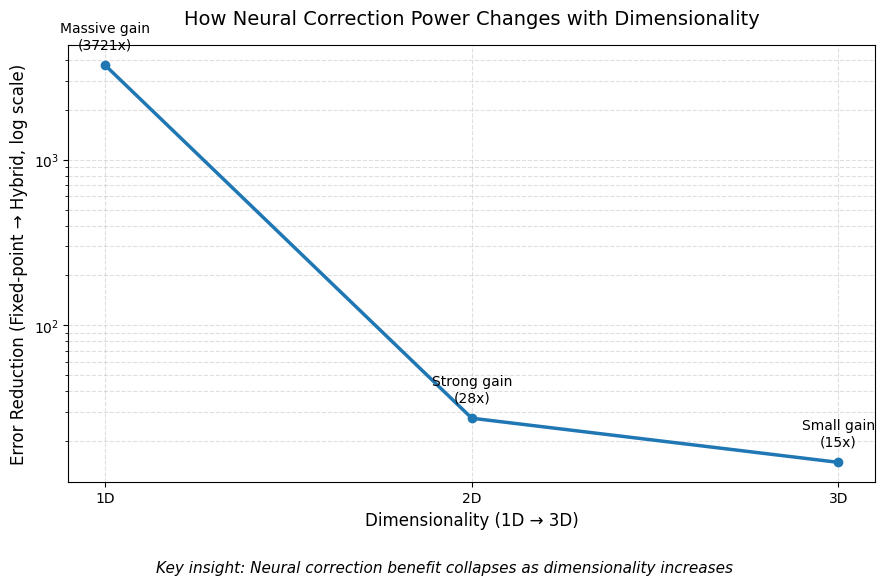

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data (your actual results)
# -----------------------------
dims = np.array([1, 2, 3])

fixed_point = np.array([
    0.126506,  # 1D
    0.385821,  # 2D
    0.262270   # 3D
])

hybrid = np.array([
    0.000034,  # 1D
    0.014027,  # 2D
    0.017616   # 3D
])

# Improvement factor
improvement = fixed_point / hybrid

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 5.5))

# Main line (clean + bold)
plt.plot(
    dims,
    improvement,
    marker='o',
    linewidth=2.5
)

# Log scale makes structure readable (VERY important here)
plt.yscale("log")

# Titles (human readable, not technical)
plt.title(
    "How Neural Correction Power Changes with Dimensionality",
    fontsize=14,
    pad=15
)

plt.xlabel("Dimensionality (1D → 3D)", fontsize=12)
plt.ylabel("Error Reduction (Fixed-point → Hybrid, log scale)", fontsize=12)

plt.xticks([1, 2, 3], ["1D", "2D", "3D"])

plt.grid(True, which="both", linestyle="--", alpha=0.4)

# -----------------------------
# Key annotations (what people read first)
# -----------------------------
labels = [
    "Massive gain",
    "Strong gain",
    "Small gain"
]

for x, y, label in zip(dims, improvement, labels):
    plt.annotate(
        f"{label}\n({y:.0f}x)",
        (x, y),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontsize=10
    )

# -----------------------------
# Clean takeaway on figure
# -----------------------------
plt.figtext(
    0.5,
    -0.05,
    "Key insight: Neural correction benefit collapses as dimensionality increases",
    ha="center",
    fontsize=11,
    style="italic"
)

plt.tight_layout()
plt.show()